# Blueprint Beta Image Captioning — MobileCLIP-S0 + PixelShuffle Pooling + SmolLM2-135M

This notebook implements the **Blueprint Beta** image-captioning design with the revised training schedule below.

- **Stage 1: 3 epochs** — connector-only cross-modal alignment; MobileCLIP-S0 and SmolLM2 remain frozen.
- **Stage 2: maximum 2 epochs** — connector + LoRA adaptation with stronger augmentation, weight decay and dropout.
- **Maximum global training length: 5 epochs.**
- Stage 2 also has validation-loss early stopping, but the hard ceiling remains 2 epochs.
- Physical batch size is benchmarked on the actual Kaggle GPU over **48, 64, 80, 96** and the largest fitting candidate is selected.
- Learning rates are scaled linearly relative to the previous validated batch size of 48.
- Text training/generation now uses an explicit BOS token after the visual prefix.
- Stage-2 LoRA includes a small low-rank adapter on `lm_head`; the pretrained head weights remain frozen.


## Why the baseline is being changed

The supplied design document identifies three interacting problems in the previous DINOv2 + Tiny-LLM design: the Tiny-LLM decoder has very limited linguistic capacity, a single linear visual projection is too weak for cross-modal alignment, and feeding 256 uncompressed visual tokens causes attention dilution. The document therefore recommends aggressively compressing the visual prefix to 64 tokens and using a stronger language backend.

Blueprint Beta specifically uses a semantically aligned MobileCLIP-family vision encoder, a PixelShuffle-style spatial token reducer, and SmolLM2-135M as the causal decoder. The document also prescribes a two-stage optimization schedule with the visual encoder frozen in both stages.

## Hardware target and optimization changes

Target runtime: Kaggle single GPU, approximately **16 GB advertised VRAM** and **30 GB system RAM**.

The revised run is tuned around the previous metrics: extra Stage-1 alignment time, a shorter Stage 2, stronger Stage-2 regularization, earlier cosine decay, and larger physical batch candidates.


# 1. Installation and imports

The notebook uses `timm` for the official MobileCLIP-S0 TIMM checkpoint, `transformers` for SmolLM2-135M, and `peft` for compact LoRA adapters in Stage 2.

In [1]:
# Kaggle: enable Internet before running this cell because pretrained checkpoints are downloaded from Hugging Face.
!pip install -q -U "timm>=1.0.19" "transformers>=4.45" "peft>=0.13" "accelerate>=0.34" "huggingface_hub>=0.24" "safetensors>=0.4" "tqdm>=4.66"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 835.4/835.4 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.3/125.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 68.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the

In [2]:
!pip install --upgrade "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 35.4 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [3]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import gc
import json
import math
import time
import random
import shutil
import csv
from pathlib import Path
from datetime import datetime
from textwrap import shorten

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import psutil

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

import timm
from timm.data import create_transform, resolve_model_data_config

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    get_cosine_schedule_with_warmup,
)
from peft import LoraConfig, TaskType, get_peft_model, get_peft_model_state_dict, set_peft_model_state_dict

import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

torch.set_float32_matmul_precision("high")

# Single GPU only, even if Kaggle exposes T4 x2.
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

assert torch.cuda.is_available(), "GPU is required for this notebook. Enable a Kaggle GPU runtime."
device = torch.device("cuda:0")

GPU_NAME = torch.cuda.get_device_name(0)
GPU_TOTAL_GB = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
print(f"Device: {device}")
print(f"GPU: {GPU_NAME}")
print(f"Reported VRAM: {GPU_TOTAL_GB:.2f} GB")
print(f"PyTorch: {torch.__version__}")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


Device: cuda:0
GPU: Tesla T4
Reported VRAM: 14.56 GB
PyTorch: 2.10.0+cu128


# 2. Configuration

The model names below are deliberately explicit. The language checkpoint is the base **`HuggingFaceTB/SmolLM2-135M`**, matching the blueprint name in the supplied PDF. The notebook does not replace it with a larger instruct variant.

The checkpoint strategy stores only the trainable multimodal components (connector + LoRA adapters) and optimizer/scheduler state. The large pretrained base models are reloaded from their public model IDs when the notebook starts, so repeated checkpoints do not consume Kaggle disk space.

In [4]:
# -----------------------------
# Data paths — Updated for your coco-2017-dataset
# -----------------------------
trainval_image_dir = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017"
trainval_captions_filepath = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/captions_train2017.json"
test_image_dir = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017"
test_captions_filepath = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/captions_val2017.json"

assert os.path.isdir(trainval_image_dir), f"Missing train image directory: {trainval_image_dir}"
assert os.path.isfile(trainval_captions_filepath), f"Missing train annotations: {trainval_captions_filepath}"
assert os.path.isdir(test_image_dir), f"Missing validation/test image directory: {test_image_dir}"
assert os.path.isfile(test_captions_filepath), f"Missing test annotations: {test_captions_filepath}"

# -----------------------------
# Blueprint Beta components
# -----------------------------
VISION_MODEL_NAME = "hf_hub:apple/mobileclip_s0_timm"
TEXT_MODEL_NAME = "HuggingFaceTB/SmolLM2-135M"

IMAGE_SIZE = 256
TARGET_VISUAL_GRID = 16          # 16x16 feature map -> PixelUnshuffle(2) -> 8x8 = 64 tokens
PIXEL_UNSHUFFLE_FACTOR = 2
NUM_VISUAL_TOKENS = (TARGET_VISUAL_GRID // PIXEL_UNSHUFFLE_FACTOR) ** 2

MAX_CAPTION_TOKENS = 32
MAX_PROMPT_TOKENS = 16

# One explicit BOS token is inserted after the visual prefix:
# [visual prefix] + [BOS] + [prompt] + [caption] + [EOS]
MAX_TEXT_TOKENS = MAX_CAPTION_TOKENS + MAX_PROMPT_TOKENS + 2

# Curriculum
STAGE1_EPOCHS = 3               # extended connector-only cross-modal alignment
STAGE2_EPOCHS = 2               # capped connector + LoRA caption-instruction tuning

# Optimization
LR_REFERENCE_BATCH_SIZE = 48
BASE_STAGE1_LR = 1e-3
BASE_STAGE2_CONNECTOR_LR = 5e-4
BASE_STAGE2_LORA_LR = 2e-4
STAGE1_WEIGHT_DECAY = 0.01
STAGE2_WEIGHT_DECAY = 0.05
CONNECTOR_STAGE1_DROPOUT = 0.00
CONNECTOR_STAGE2_DROPOUT = 0.10
STAGE2_PATIENCE = 1
STAGE2_MIN_DELTA = 1e-4
MAX_GRAD_NORM = 1.0
LABEL_SMOOTHING = 0.0            # keep standard CE as specified in the source methodology

# T4 AMP
AMP_DTYPE = torch.bfloat16
USE_AMP = True

# LoRA for the 135M causal decoder.
# The pretrained LM head remains frozen, but receives a small low-rank
# adapter so the output distribution can specialize to image captioning
# without replacing the pretrained vocabulary head.
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.10
ADAPT_LM_HEAD = False

LORA_TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj",
]

if ADAPT_LM_HEAD:
    LORA_TARGET_MODULES.append("lm_head")

# DataLoader
NUM_WORKERS = min(4, os.cpu_count() or 2)
PIN_MEMORY = True
PERSISTENT_WORKERS = NUM_WORKERS > 0
PREFETCH_FACTOR = 2

# Runtime batch search. The selected physical batch is a Stage-2-aware value.
AUTO_TUNE_BATCH = True
BATCH_CANDIDATES = [48, 64, 80, 96]
DEFAULT_BATCH_SIZE = 48
VRAM_SAFETY_FRACTION = 0.88       # keep headroom below the 15GB T4 ceiling
BATCH_BENCHMARK_STEPS = 2

# Checkpointing: overwrite one resume file; save one best file per stage.
# UPDATED: Changed WORK_DIR to your preferred alpha_captioner output directory
WORK_DIR = Path("/kaggle/working/alpha_captioner")
CHECKPOINT_DIR = WORK_DIR / "blueprint_beta_checkpoints"
ARTIFACT_DIR = WORK_DIR / "blueprint_beta_artifacts"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

RESUME_PATH = CHECKPOINT_DIR / "last.pt"
STAGE1_BEST_PATH = CHECKPOINT_DIR / "stage1_best.pt"
STAGE2_BEST_PATH = CHECKPOINT_DIR / "stage2_best.pt"
CONFIG_PATH = ARTIFACT_DIR / "run_config.json"
METRICS_PATH = ARTIFACT_DIR / "metrics.csv"
LOG_PATH = ARTIFACT_DIR / "training.log"
FINAL_PATH = CHECKPOINT_DIR / "beta_final.pt"

# Compact qualitative record per epoch.
NUM_VISUAL_SAMPLES_PER_EPOCH = 6

# Caption prompts: Stage 1 is stable; Stage 2 uses light prompt variation because the available
# training source is COCO captions rather than a separate instruction-tuning corpus.
STAGE1_PROMPT = "Describe the image:"
STAGE2_PROMPTS = [
    "Write a concise caption for this image:",
    "What is shown in this image?",
    "Describe the main scene in one sentence:",
]

print(f"Stage 1 epochs: {STAGE1_EPOCHS}")
print(f"Stage 2 epochs: {STAGE2_EPOCHS}")
print(f"Maximum global epochs: {STAGE1_EPOCHS + STAGE2_EPOCHS}")
print(f"Worker count: {NUM_WORKERS}")
print(f"Candidate physical batches: {BATCH_CANDIDATES}")

Stage 1 epochs: 3
Stage 2 epochs: 2
Maximum global epochs: 5
Worker count: 4
Candidate physical batches: [48, 64, 80, 96]


# 3. Load and split the COCO annotations

The reference notebook uses an image-level 80/20 split of `train2014`. This notebook keeps that split strategy so the validation images remain disjoint from training images.

A key efficiency change is that the training dataset is **image-indexed rather than caption-row-indexed**. COCO has multiple captions per image; processing the same pixels five times per epoch is wasteful for a memory-constrained multimodal model. One caption is selected per image each epoch and the selected caption rotates across epochs.

In [5]:
with open(trainval_captions_filepath, "r") as f:
    trainval_data = json.load(f)

trainval_ann = pd.json_normalize(trainval_data, "annotations")
trainval_ann["image_filepath"] = trainval_ann["image_id"].apply(
    # UPDATED: Dropped the COCO_train2014_ prefix to match COCO 2017 naming format
    lambda x: os.path.join(trainval_image_dir, f"{int(x):012d}.jpg")
)
trainval_ann["clean_caption"] = (
    trainval_ann["caption"].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
)

# Image-level split: deterministic and reproducible.
all_image_paths = np.array(sorted(trainval_ann["image_filepath"].unique()))
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(all_image_paths))
split = int(len(all_image_paths) * 0.80)
train_image_paths = set(all_image_paths[perm[:split]])
valid_image_paths = set(all_image_paths[perm[split:]])

train_ann = trainval_ann[trainval_ann["image_filepath"].isin(train_image_paths)].copy()
valid_ann = trainval_ann[trainval_ann["image_filepath"].isin(valid_image_paths)].copy()

with open(test_captions_filepath, "r") as f:
    test_data = json.load(f)

test_ann = pd.json_normalize(test_data, "annotations")
test_ann["image_filepath"] = test_ann["image_id"].apply(
    lambda x: os.path.join(test_image_dir, f"{int(x):012d}.jpg")
)
test_ann["clean_caption"] = (
    test_ann["caption"].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
)

print(f"Train images: {len(train_image_paths):,}")
print(f"Validation images: {len(valid_image_paths):,}")
print(f"Train caption rows: {len(train_ann):,}")
print(f"Validation caption rows: {len(valid_ann):,}")
print(f"Test caption rows: {len(test_ann):,}")

Train images: 94,629
Validation images: 23,658
Train caption rows: 473,393
Validation caption rows: 118,360
Test caption rows: 25,014


In [6]:
def group_captions(ann_df):
    groups = []
    for image_path, g in ann_df.groupby("image_filepath", sort=False):
        captions = [c for c in g["clean_caption"].tolist() if c]
        if captions and os.path.isfile(image_path):
            groups.append((image_path, captions))
    return groups

train_groups = group_captions(train_ann)
valid_groups = group_captions(valid_ann)
test_groups = group_captions(test_ann)

print(f"Usable train image groups: {len(train_groups):,}")
print(f"Usable validation image groups: {len(valid_groups):,}")
print(f"Usable test image groups: {len(test_groups):,}")

Usable train image groups: 94,629
Usable validation image groups: 23,658
Usable test image groups: 5,000


# 4. MobileCLIP-S0 vision backbone

The supplied PDF specifies an 11.4M-parameter MobileCLIP variant. The current official MobileCLIP table identifies that configuration as **MobileCLIP-S0**; its official TIMM checkpoint is `apple/mobileclip_s0_timm`. The checkpoint is a FastViT image encoder with a 256×256 input and an 8×8 pooled output, but the captioner needs a **16×16 spatial map before final pooling** so the blueprint’s space-to-depth operation can reduce 16×16 → 8×8 = 64 tokens.

The notebook therefore creates the MobileCLIP-S0 backbone with `features_only=True`, inspects its feature pyramid, and selects the feature map whose spatial resolution is 16×16. This avoids hard-coding an internal channel width that may change across TIMM versions.

In [7]:
# Load the frozen MobileCLIP-S0 image encoder as a TIMM feature pyramid.
vision_encoder = timm.create_model(
    VISION_MODEL_NAME,
    pretrained=True,
    features_only=True,
)
vision_encoder.eval()
vision_encoder.requires_grad_(False)

# Use the official preprocessing configuration associated with the checkpoint.
vision_data_config = resolve_model_data_config(vision_encoder)

# Deterministic validation/inference transform.
vision_transform_eval = create_transform(**vision_data_config, is_training=False)

# Moderate augmentation for Stage 1 alignment.
vision_transform_stage1 = create_transform(
    **vision_data_config, is_training=True, hflip=0.5, color_jitter=0.10, re_prob=0.05
)

# Stronger Stage-2 augmentation to combat overfitting.
vision_transform_stage2 = create_transform(
    **vision_data_config, is_training=True, hflip=0.5, color_jitter=0.20, re_prob=0.15, re_mode="pixel"
)

vision_transform = vision_transform_eval

# Inspect available feature maps and select the 16x16 representation.
with torch.no_grad():
    dummy = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)
    feature_pyramid = vision_encoder(dummy)

feature_shapes = [tuple(f.shape) for f in feature_pyramid]
print("Feature pyramid:", feature_shapes)

candidate_indices = [
    i for i, f in enumerate(feature_pyramid)
    if f.ndim == 4 and f.shape[-2] == TARGET_VISUAL_GRID and f.shape[-1] == TARGET_VISUAL_GRID
]
assert candidate_indices, (
    f"Expected a {TARGET_VISUAL_GRID}x{TARGET_VISUAL_GRID} MobileCLIP feature map, "
    f"but available shapes are {feature_shapes}."
)
FEATURE_INDEX = candidate_indices[-1]
VISION_CHANNELS = int(feature_pyramid[FEATURE_INDEX].shape[1])

print(f"Selected feature index: {FEATURE_INDEX}")
print(f"Selected feature map: {TARGET_VISUAL_GRID}x{TARGET_VISUAL_GRID} with {VISION_CHANNELS} channels")
print(f"Expected visual tokens after PixelUnshuffle({PIXEL_UNSHUFFLE_FACTOR}): {NUM_VISUAL_TOKENS}")

# Move the frozen vision tower to the GPU only after shape inspection.
vision_encoder = vision_encoder.to(device)
vision_encoder.eval()

config.json:   0%|          | 0.00/644 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 46.1MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Feature pyramid: [(1, 64, 64, 64), (1, 128, 32, 32), (1, 256, 16, 16), (1, 512, 8, 8)]
Selected feature index: 2
Selected feature map: 16x16 with 256 channels
Expected visual tokens after PixelUnshuffle(2): 64


FeatureListNet(
  (stem_0): MobileOneBlock(
    (se): Identity()
    (conv_kxk): ModuleList(
      (0): ConvNormAct(
        (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNormAct2d(
          64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): Identity()
        )
      )
    )
    (conv_scale): ConvNormAct(
      (conv): Conv2d(3, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (bn): BatchNormAct2d(
        64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): Identity()
      )
    )
    (act): GELU(approximate='none')
  )
  (stem_1): MobileOneBlock(
    (se): Identity()
    (conv_kxk): ModuleList(
      (0): ConvNormAct(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=64, bias=False)
        (bn): BatchNormAct2d(
          64, eps=1e-05, momentum=0.1, affine=True

# 5. SmolLM2-135M language backbone

The SmolLM2-135M configuration is a deep/narrow Llama-style causal decoder (30 layers, hidden size 576 in the current checkpoint). The visual prefix is inserted as `inputs_embeds` before the text prompt, so the language model sees the image tokens as a causal prefix exactly as specified in Blueprint Beta.

In [8]:
text_tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME, use_fast=True)
if text_tokenizer.pad_token is None:
    text_tokenizer.pad_token = text_tokenizer.eos_token

text_decoder = AutoModelForCausalLM.from_pretrained(
    TEXT_MODEL_NAME,
    low_cpu_mem_usage=True,
    torch_dtype=AMP_DTYPE,
)
text_decoder.config.use_cache = True
text_decoder.to(device)

TEXT_HIDDEN = int(text_decoder.config.hidden_size)
print(f"SmolLM2 hidden size: {TEXT_HIDDEN}")
print(f"SmolLM2 vocab size: {text_decoder.config.vocab_size}")
print(f"SmolLM2 layers: {text_decoder.config.num_hidden_layers}")
print(f"SmolLM2 attention heads: {text_decoder.config.num_attention_heads}")
print(f"SmolLM2 params: {sum(p.numel() for p in text_decoder.parameters()) / 1e6:.2f}M")

config.json:   0%|          | 0.00/704 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.66k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  269MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

SmolLM2 hidden size: 576
SmolLM2 vocab size: 49152
SmolLM2 layers: 30
SmolLM2 attention heads: 9
SmolLM2 params: 134.52M


# 6. Beta connector: space-to-depth → linear projection

The PDF’s “PixelShuffle Pooling” description uses the **space-to-depth** operation. In PyTorch, space-to-depth is implemented as `nn.PixelUnshuffle`, while `nn.PixelShuffle` performs the inverse depth-to-space transform.

For a `16×16×C` feature map:

\[
X \in \mathbb{R}^{B\times C\times16\times16}
\xrightarrow{\text{PixelUnshuffle}(2)}
X' \in \mathbb{R}^{B\times4C\times8\times8}
\]

Flattening the 8×8 spatial grid yields exactly 64 visual tokens, followed by a linear map to the SmolLM2 hidden size. A final LayerNorm is retained as a numerical stabilization step for the randomly initialized bridge; it does not alter token count or modality geometry.

In [9]:
class BetaPixelShuffleConnector(nn.Module):
    """Blueprint Beta connector: 16x16 feature map -> 64 visual tokens -> LLM hidden size."""
    def __init__(self, in_channels, llm_hidden, downscale=2, dropout=0.0):
        super().__init__()
        self.downscale = downscale
        self.unshuffle = nn.PixelUnshuffle(downscale)
        self.proj = nn.Linear(in_channels * (downscale ** 2), llm_hidden)
        self.norm = nn.LayerNorm(llm_hidden)
        self.dropout = nn.Dropout(dropout)

    def set_dropout(self, probability):
        self.dropout.p = float(probability)

    def forward(self, x):
        # x: [B, C, 16, 16]
        assert x.ndim == 4, f"Expected NCHW tensor, got {x.shape}"
        x = self.unshuffle(x)                         # [B, 4C, 8, 8]
        x = x.flatten(2).transpose(1, 2).contiguous() # [B, 64, 4C]
        x = self.proj(x)                              # [B, 64, hidden]
        x = self.dropout(x)                           # FIX: Dropout BEFORE LayerNorm
        x = self.norm(x)                              # FIX: Re-normalize variance to protect FP16 LLM
        return x

connector = BetaPixelShuffleConnector(
    in_channels=VISION_CHANNELS,
    llm_hidden=TEXT_HIDDEN,
    downscale=PIXEL_UNSHUFFLE_FACTOR,
    dropout=CONNECTOR_STAGE1_DROPOUT,
).to(device)

with torch.no_grad():
    probe = feature_pyramid[FEATURE_INDEX].to(device)
    probe_tokens = connector(probe)
print(f"Connector output shape: {tuple(probe_tokens.shape)}")
assert probe_tokens.shape[1] == NUM_VISUAL_TOKENS
assert probe_tokens.shape[2] == TEXT_HIDDEN

del probe, probe_tokens, feature_pyramid, dummy

Connector output shape: (1, 64, 576)


# 7. COCO dataset and fast batch collation

The dataset is image-indexed. Each epoch, `set_epoch()` selects one of the available COCO captions for each image. A batch therefore contains unique image tensors rather than five copies of the same image.

Tokenization is performed in the collate function so it can be vectorized over the batch. Labels are `-100` for image-prefix and prompt positions; the cross-entropy therefore trains only on the ground-truth caption tokens.

In [10]:
class CocoImageCaptionDataset(Dataset):
    def __init__(self, groups, transform_eval, transform_stage1, transform_stage2, stage="stage1", seed=SEED):
        self.groups = groups
        self.transform_eval = transform_eval
        self.transform_stage1 = transform_stage1
        self.transform_stage2 = transform_stage2
        self.stage = stage
        self.seed = seed
        self.epoch = 0

    def set_stage(self, stage):
        self.stage = stage

    def set_epoch(self, epoch):
        self.epoch = int(epoch)

    def __len__(self):
        return len(self.groups)

    def __getitem__(self, idx):
        image_path, captions = self.groups[idx]
        image = Image.open(image_path).convert("RGB")
        if self.stage == "stage1":
            transform = self.transform_stage1
        elif self.stage == "stage2":
            transform = self.transform_stage2
        else:
            transform = self.transform_eval
        pixel_values = transform(image)

        # Rotate captions so repeated epochs do not repeatedly train on the same sentence.
        caption_idx = (idx + self.epoch) % len(captions)
        caption = captions[caption_idx]

        if self.stage in {"stage1", "eval"}:
            prompt = STAGE1_PROMPT
        else:
            prompt = STAGE2_PROMPTS[(idx + self.epoch) % len(STAGE2_PROMPTS)]

        return {
            "pixel_values": pixel_values,
            "image_filepath": image_path,
            "caption": caption,
            "prompt": prompt,
        }


def build_text_batch(
    prompts,
    captions,
    tokenizer,
    max_prompt_tokens=MAX_PROMPT_TOKENS,
    max_caption_tokens=MAX_CAPTION_TOKENS,
):
    """
    Construct [BOS] + prompt + caption+EOS token sequences.

    The multimodal model places these tokens after the visual prefix:

        [64 visual tokens] + [BOS] + [prompt] + [caption] + [EOS]

    Only caption tokens contribute to the cross-entropy loss.
    """
    pad_id = tokenizer.pad_token_id
    bos_id = tokenizer.bos_token_id
    eos_id = tokenizer.eos_token_id

    if bos_id is None:
        raise ValueError(
            "SmolLM2 tokenizer does not expose a BOS token. "
            "The updated training path requires an explicit BOS token."
        )

    seqs, labels = [], []

    for prompt, caption in zip(prompts, captions):

        p = tokenizer(
            prompt,
            add_special_tokens=False,
            truncation=True,
            max_length=max_prompt_tokens,
        )["input_ids"]

        c = tokenizer(
            caption,
            add_special_tokens=False,
            truncation=True,
            max_length=max_caption_tokens - 1,
        )["input_ids"]

        c = c + [eos_id]

        seq = [bos_id] + p + c
        lab = [-100] * (1 + len(p)) + c

        seqs.append(seq)
        labels.append(lab)

    max_len = min(
        MAX_TEXT_TOKENS,
        max(len(s) for s in seqs),
    )

    input_ids = []
    attention = []
    label_ids = []

    for seq, lab in zip(seqs, labels):

        seq = seq[:max_len]
        lab = lab[:max_len]

        pad_n = max_len - len(seq)

        input_ids.append(
            seq + [pad_id] * pad_n
        )

        attention.append(
            [1] * len(seq)
            + [0] * pad_n
        )

        label_ids.append(
            lab + [-100] * pad_n
        )

    return {
        "input_ids": torch.tensor(
            input_ids,
            dtype=torch.long,
        ),
        "attention_mask": torch.tensor(
            attention,
            dtype=torch.long,
        ),
        "labels": torch.tensor(
            label_ids,
            dtype=torch.long,
        ),
    }


def collate_fn(batch):
    pixel_values = torch.stack([x["pixel_values"] for x in batch])
    image_filepaths = [x["image_filepath"] for x in batch]
    captions = [x["caption"] for x in batch]
    prompts = [x["prompt"] for x in batch]
    text = build_text_batch(prompts, captions, text_tokenizer)
    text.update({
        "pixel_values": pixel_values,
        "image_filepaths": image_filepaths,
        "raw_captions": captions,
        "prompts": prompts,
    })
    return text

train_dataset = CocoImageCaptionDataset(
    train_groups,
    transform_eval=vision_transform_eval,
    transform_stage1=vision_transform_stage1,
    transform_stage2=vision_transform_stage2,
    stage="stage1",
)
valid_dataset = CocoImageCaptionDataset(
    valid_groups,
    transform_eval=vision_transform_eval,
    transform_stage1=vision_transform_stage1,
    transform_stage2=vision_transform_stage2,
    stage="eval",
)

# 8. Multimodal model

The vision encoder remains permanently frozen. In Stage 1, only the connector is trainable. In Stage 2, the connector remains trainable and SmolLM2 receives LoRA adapters; its pretrained base weights remain frozen, including the base `lm_head` weights.

The forward pass is:

1. MobileCLIP-S0 → selected 16×16 feature map.
2. PixelUnshuffle(2) → 8×8 map.
3. Flatten → 64 visual tokens.
4. Linear + LayerNorm → 64×576 visual prefix.
5. Explicit BOS + prompt + caption tokens are appended after the visual prefix.
6. Prefix + text embeddings → SmolLM2 causal decoder.
7. Cross-entropy is computed only on caption token positions.
8. Stage 2 adds low-rank adapters to the attention/MLP projections and `lm_head`.

In [11]:
class BetaCaptioner(nn.Module):
    def __init__(self, vision_encoder, feature_index, connector, text_decoder, tokenizer):
        super().__init__()
        self.vision_encoder = vision_encoder
        self.feature_index = feature_index
        self.connector = connector
        self.text_decoder = text_decoder
        self.tokenizer = tokenizer

    def encode_visual(self, pixel_values):
        # The vision encoder is frozen and kept in eval mode because FastViT uses BatchNorm.
        self.vision_encoder.eval()
        with torch.no_grad():
            features = self.vision_encoder(pixel_values)
            fmap = features[self.feature_index]
        visual_tokens = self.connector(fmap)
        return visual_tokens

    def forward(self, pixel_values, input_ids, attention_mask, labels=None):
        visual_tokens = self.encode_visual(pixel_values)
        text_embeds = self.text_decoder.get_input_embeddings()(input_ids)
        inputs_embeds = torch.cat([visual_tokens, text_embeds], dim=1)

        image_mask = torch.ones(
            pixel_values.size(0), visual_tokens.size(1),
            dtype=attention_mask.dtype, device=attention_mask.device,
        )
        full_attention = torch.cat([image_mask, attention_mask], dim=1)

        outputs = self.text_decoder(
            inputs_embeds=inputs_embeds,
            attention_mask=full_attention,
            use_cache=False,
        )

        if labels is None:
            return outputs

        # Labels are aligned with text positions only; prefix positions are always ignored.
        # Labels are aligned with text positions only; prefix positions are always ignored.
        prefix_ignored = torch.full(
            (labels.size(0), visual_tokens.size(1)),
            -100,
            dtype=labels.dtype,
            device=labels.device,
        )
        full_labels = torch.cat([prefix_ignored, labels], dim=1)

        # FIX: Cast logits to float32 before cross_entropy to prevent FP16 overflow
        shift_logits = outputs.logits[:, :-1, :].contiguous().to(torch.float32)
        shift_labels = full_labels[:, 1:].contiguous()
        
        loss = F.cross_entropy(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
            ignore_index=-100,
        )
        return loss, outputs

    @torch.no_grad()
    def generate_caption(
        self,
        pixel_values,
        prompt,
        max_new_tokens=30,
    ):
        self.vision_encoder.eval()
        self.text_decoder.eval()

        visual_tokens = self.encode_visual(
            pixel_values
        )

        bos_id = self.tokenizer.bos_token_id

        if bos_id is None:
            raise ValueError(
                "SmolLM2 tokenizer does not expose a BOS token. "
                "Generation requires the same explicit BOS convention used in training."
            )

        prompt_ids = self.tokenizer(
            prompt,
            return_tensors="pt",
            add_special_tokens=False,
        )["input_ids"].to(
            pixel_values.device
        )

        bos = torch.full(
            (prompt_ids.size(0), 1),
            bos_id,
            dtype=prompt_ids.dtype,
            device=pixel_values.device,
        )

        prompt_ids = torch.cat(
            [bos, prompt_ids],
            dim=1,
        )

        prompt_embeds = (
            self.text_decoder
            .get_input_embeddings()(prompt_ids)
        )

        inputs_embeds = torch.cat(
            [visual_tokens, prompt_embeds],
            dim=1,
        )

        # Explicitly track the full causal attention mask during
        # cached decoding. This prevents transformers from repeatedly
        # warning that attention_mask was omitted.
        attention = torch.ones(
            inputs_embeds.shape[:2],
            dtype=torch.long,
            device=pixel_values.device,
        )

        out = self.text_decoder(
            inputs_embeds=inputs_embeds,
            attention_mask=attention,
            use_cache=True,
        )

        past = out.past_key_values

        next_token = torch.argmax(
            out.logits[:, -1, :],
            dim=-1,
            keepdim=True,
        )

        generated = [next_token]

        for _ in range(max_new_tokens - 1):

            next_embed = (
                self.text_decoder
                .get_input_embeddings()(next_token)
            )

            attention = torch.cat(
                [
                    attention,
                    torch.ones(
                        (attention.size(0), 1),
                        dtype=attention.dtype,
                        device=attention.device,
                    ),
                ],
                dim=1,
            )

            out = self.text_decoder(
                inputs_embeds=next_embed,
                attention_mask=attention,
                past_key_values=past,
                use_cache=True,
            )

            past = out.past_key_values

            next_token = torch.argmax(
                out.logits[:, -1, :],
                dim=-1,
                keepdim=True,
            )

            generated.append(
                next_token
            )

            if torch.all(
                next_token.squeeze(-1)
                == self.tokenizer.eos_token_id
            ):
                break

        generated_ids = torch.cat(
            generated,
            dim=1,
        )

        return self.tokenizer.batch_decode(
            generated_ids,
            skip_special_tokens=True,
        )


# LoRA wrappers are installed before batch auto-tuning so the selected batch is valid for Stage 2.
# The pretrained LM head stays frozen; when ADAPT_LM_HEAD=True only a low-rank
# adapter attached to lm_head is trainable.
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES,
    bias="none",
)
text_decoder = get_peft_model(text_decoder, lora_config)
text_decoder.print_trainable_parameters()

model = BetaCaptioner(
    vision_encoder=vision_encoder,
    feature_index=FEATURE_INDEX,
    connector=connector,
    text_decoder=text_decoder,
    tokenizer=text_tokenizer,
).to(device)

# Permanent freeze for the vision tower.
model.vision_encoder.requires_grad_(False)
model.vision_encoder.eval()

trainable params: 2,442,240 || all params: 136,957,248 || trainable%: 1.7832


FeatureListNet(
  (stem_0): MobileOneBlock(
    (se): Identity()
    (conv_kxk): ModuleList(
      (0): ConvNormAct(
        (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNormAct2d(
          64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): Identity()
        )
      )
    )
    (conv_scale): ConvNormAct(
      (conv): Conv2d(3, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (bn): BatchNormAct2d(
        64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): Identity()
      )
    )
    (act): GELU(approximate='none')
  )
  (stem_1): MobileOneBlock(
    (se): Identity()
    (conv_kxk): ModuleList(
      (0): ConvNormAct(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=64, bias=False)
        (bn): BatchNormAct2d(
          64, eps=1e-05, momentum=0.1, affine=True

# 8A. Model math and optimization geometry

Let the selected MobileCLIP feature map be

\[
X_v \in \mathbb{R}^{B\times C\times16\times16}.
\]

The Blueprint Beta space-to-depth step is

\[
X_u = \operatorname{PixelUnshuffle}_2(X_v) \in \mathbb{R}^{B\times4C\times8\times8}.
\]

Flatten the spatial grid:

\[
U \in \mathbb{R}^{B\times64\times4C}.
\]

The trainable bridge maps each compressed visual token to SmolLM2’s hidden dimension $d=576$:

\[
Z_v = \operatorname{LN}(UW_p + b_p) \in \mathbb{R}^{B\times64\times576}.
\]

Let $E(\cdot)$ be the frozen SmolLM2 input embedding table and $T$ be the explicit BOS + prompt + caption token sequence. Then

\[
Z_t = E(T), \qquad Z = [Z_v;Z_t].
\]

The causal decoder receives $Z$ as `inputs_embeds`. The visual prefix occupies the first 64 causal positions; caption tokens can attend to the entire visual prefix and all preceding text tokens.

For target labels $y_t$, prompt/image positions are ignored and only caption tokens contribute:

\[
\mathcal{L}= -\frac{1}{N}\sum_{t:\,y_t\neq -100} \log p_\theta(y_t\mid Z_{\le t}).
\]

The staged gradient constraints are:

- **Stage 1:** $\nabla_{\theta_v}=0$, $\nabla_{\theta_{LLM}}=0$, optimize only $\theta_p$ (connector).
- **Stage 2:** $\nabla_{\theta_v}=0$, keep pretrained LLM base weights frozen, optimize $\theta_p$ and low-rank LoRA parameters $\theta_{LoRA}$, including an adapter on `lm_head`.

For the batch search, the notebook measures the actual peak memory function $M(B)$ on the target runtime and accepts a candidate only when $M(B) \le 0.84\,M_{GPU}$; this is why the selected physical batch size is a measured hardware result rather than a hard-coded claim.

# 9. DataLoader factory and Stage-2-aware batch-size benchmark

The physical batch-size search uses a real batch from the current dataset and runs the actual multimodal forward/backward graph with LoRA enabled. A candidate is accepted only if:

- it completes without OOM, and
- its peak allocated VRAM remains below the configured safety ceiling.

The largest accepted candidate is used. A short timing pass also reports images/second for every candidate, so the notebook shows the measured trade-off rather than claiming a universal “optimal” batch size.

In [12]:
def make_loader(dataset, batch_size, shuffle, drop_last=False):
    kwargs = dict(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=drop_last,
        collate_fn=collate_fn,
    )
    if NUM_WORKERS > 0:
        kwargs["persistent_workers"] = PERSISTENT_WORKERS
        kwargs["prefetch_factor"] = PREFETCH_FACTOR
    return DataLoader(**kwargs)

# Probe Stage-2 text lengths so the selected batch is valid for the heavier training stage.
train_dataset.set_stage("stage2")
probe_loader = make_loader(train_dataset, max(BATCH_CANDIDATES), shuffle=True, drop_last=False)
probe_batch = next(iter(probe_loader))

batch_memory_limit_gb = GPU_TOTAL_GB * VRAM_SAFETY_FRACTION
print(f"VRAM benchmark ceiling: {batch_memory_limit_gb:.2f} GB ({VRAM_SAFETY_FRACTION:.0%} of reported GPU memory)")


def move_batch(batch):
    return {
        "pixel_values": batch["pixel_values"].to(device, non_blocking=True),
        "input_ids": batch["input_ids"].to(device, non_blocking=True),
        "attention_mask": batch["attention_mask"].to(device, non_blocking=True),
        "labels": batch["labels"].to(device, non_blocking=True),
    }


def _slice_batch_item(value, n):
    """
    Slice tensor payloads and Python-side metadata to the same
    logical batch size.

    The collated benchmark batch contains tensors plus lists such as
    image_filepaths/raw_captions/prompts. All fields are kept aligned.
    """
    if torch.is_tensor(value):
        return value[:n]

    if isinstance(value, list):
        return value[:n]

    if isinstance(value, tuple):
        return value[:n]

    return value


def benchmark_batch_size(
    candidate_bs,
    source_batch,
):
    """Return (fits, peak_gb, examples_per_sec)."""

    torch.cuda.empty_cache()
    gc.collect()
    torch.cuda.reset_peak_memory_stats()

    batch = {
        key: _slice_batch_item(
            value,
            candidate_bs,
        )
        for key, value in source_batch.items()
    }

    tensor_sizes = [
        value.size(0)
        for value in batch.values()
        if torch.is_tensor(value)
        and value.ndim > 0
    ]

    if any(
        size != candidate_bs
        for size in tensor_sizes
    ):
        raise RuntimeError(
            "Benchmark tensor size mismatch: "
            f"expected {candidate_bs}, "
            f"got {tensor_sizes}"
        )

    metadata_sizes = [
        len(value)
        for value in batch.values()
        if isinstance(value, (list, tuple))
    ]

    if any(
        size != candidate_bs
        for size in metadata_sizes
    ):
        raise RuntimeError(
            "Benchmark metadata size mismatch: "
            f"expected {candidate_bs}, "
            f"got {metadata_sizes}"
        )

    batch = move_batch(batch)

    model.connector.train()
    model.connector.set_dropout(
        CONNECTOR_STAGE2_DROPOUT
    )
    model.vision_encoder.eval()
    model.text_decoder.train()
    model.zero_grad(set_to_none=True)

    start = time.perf_counter()

    try:

        for _ in range(
            BATCH_BENCHMARK_STEPS
        ):

            with torch.autocast(
                device_type="cuda",
                dtype=AMP_DTYPE,
                enabled=USE_AMP,
            ):
                loss, _ = model(
                    batch["pixel_values"],
                    batch["input_ids"],
                    batch["attention_mask"],
                    batch["labels"],
                )

            loss.backward()

            model.zero_grad(
                set_to_none=True
            )

        torch.cuda.synchronize()

        elapsed = (
            time.perf_counter() - start
        )

        peak_gb = (
            torch.cuda.max_memory_allocated()
            / (1024 ** 3)
        )

        fits = (
            peak_gb <= batch_memory_limit_gb
        )

        ex_per_sec = (
            candidate_bs
            * BATCH_BENCHMARK_STEPS
            / max(elapsed, 1e-6)
        )

        return (
            fits,
            peak_gb,
            ex_per_sec,
        )

    except RuntimeError as e:

        if "out of memory" in str(e).lower():
            return (
                False,
                float("inf"),
                0.0,
            )

        raise

    finally:

        model.zero_grad(
            set_to_none=True
        )

        del batch

        torch.cuda.empty_cache()
        gc.collect()


batch_benchmark_rows = []
if AUTO_TUNE_BATCH:
    print("Benchmarking physical batch sizes...")
    for candidate in BATCH_CANDIDATES:
        fits, peak_gb, ex_per_sec = benchmark_batch_size(candidate, probe_batch)
        row = {"batch_size": candidate, "fits": fits, "peak_vram_gb": peak_gb, "images_per_sec": ex_per_sec}
        batch_benchmark_rows.append(row)
        print(f"batch={candidate:>3} | fits={str(fits):5s} | peak={peak_gb:5.2f} GB | throughput={ex_per_sec:6.1f} img/s")
        if not fits:
            # Larger batches are monotonically harder on memory; stop probing after the first failure.
            break
    fitted = [r for r in batch_benchmark_rows if r["fits"]]
    if fitted:
        BATCH_SIZE = max(r["batch_size"] for r in fitted)
    else:
        BATCH_SIZE = DEFAULT_BATCH_SIZE
else:
    BATCH_SIZE = DEFAULT_BATCH_SIZE

train_dataset.set_stage("stage1")
LR_SCALE = BATCH_SIZE / LR_REFERENCE_BATCH_SIZE
print(f"\nSelected physical batch size: {BATCH_SIZE}")
print(f"Linear learning-rate scale vs batch 48: {LR_SCALE:.3f}x")

VRAM benchmark ceiling: 12.81 GB (88% of reported GPU memory)
Benchmarking physical batch sizes...
batch= 48 | fits=True  | peak= 8.28 GB | throughput=  19.4 img/s
batch= 64 | fits=True  | peak=10.93 GB | throughput=  24.3 img/s
batch= 80 | fits=False | peak=13.58 GB | throughput=  23.8 img/s

Selected physical batch size: 64
Linear learning-rate scale vs batch 48: 1.333x


# 10. Optimizers, schedulers, regularization, and checkpointing

Stage 1 uses lighter regularization. Stage 2 uses stronger weight decay, connector/LoRA dropout, stronger augmentation, and an earlier/steeper cosine decay. Learning rates scale linearly with the selected physical batch relative to batch 48.

Checkpoint files are compact and atomic; pretrained MobileCLIP and SmolLM2 base weights are not duplicated into every checkpoint.


In [13]:
def trainable_parameters_stage1():
    # Only the connector is optimized.
    for p in model.vision_encoder.parameters():
        p.requires_grad_(False)
    for p in model.text_decoder.parameters():
        p.requires_grad_(False)
    for p in model.connector.parameters():
        p.requires_grad_(True)
    return [p for p in model.connector.parameters() if p.requires_grad]


def trainable_parameters_stage2():
    for p in model.vision_encoder.parameters():
        p.requires_grad_(False)
    # The base SmolLM2 weights remain frozen; only PEFT LoRA matrices are trainable.
    model.text_decoder.enable_adapter_layers()
    for name, p in model.text_decoder.named_parameters():
        p.requires_grad_("lora_" in name)
    for p in model.connector.parameters():
        p.requires_grad_(True)
    lora_params = [p for n, p in model.text_decoder.named_parameters() if p.requires_grad and "lora_" in n]
    if not lora_params:
        raise RuntimeError("Stage 2 requested but no LoRA parameters are trainable.")
    return [p for p in model.parameters() if p.requires_grad]


def build_stage_optimizer(stage, total_steps):
    if stage == "stage1":
        params = trainable_parameters_stage1()
        optimizer = torch.optim.AdamW(params, lr=BASE_STAGE1_LR * LR_SCALE, weight_decay=STAGE1_WEIGHT_DECAY, betas=(0.9, 0.98), eps=1e-8)
    else:
        params = trainable_parameters_stage2()
        connector_params = [p for p in model.connector.parameters() if p.requires_grad]
        lora_params = [p for n, p in model.text_decoder.named_parameters() if p.requires_grad and "lora_" in n]
        optimizer = torch.optim.AdamW(
            [
                {"params": connector_params, "lr": BASE_STAGE2_CONNECTOR_LR * LR_SCALE},
                {"params": lora_params, "lr": BASE_STAGE2_LORA_LR * LR_SCALE},
            ],
            weight_decay=STAGE2_WEIGHT_DECAY,
            betas=(0.9, 0.98),
            eps=1e-5,
        )
    if stage == "stage2":
        warmup_fraction, decay_fraction, min_lr_ratio = 0.05, 0.60, 0.10
    else:
        warmup_fraction, decay_fraction, min_lr_ratio = 0.08, 0.90, 0.05

    warmup_steps = max(1, int(total_steps * warmup_fraction))
    decay_end_step = max(warmup_steps + 1, int(total_steps * decay_fraction))

    def lr_lambda(step):
        if step < warmup_steps:
            return float(step + 1) / float(warmup_steps)
        if step >= decay_end_step:
            return min_lr_ratio
        progress = (step - warmup_steps) / max(1, decay_end_step - warmup_steps)
        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        return min_lr_ratio + (1.0 - min_lr_ratio) * cosine

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    return optimizer, scheduler, scaler, params


def compact_checkpoint_dict(stage, epoch, global_step, optimizer, scheduler, scaler, best_val_loss):
    adapter_state = get_peft_model_state_dict(model.text_decoder)
    return {
        "format_version": 3,
        "timestamp": datetime.now().isoformat(),
        "stage": stage,
        "epoch": int(epoch),
        "global_step": int(global_step),
        "best_val_loss": float(best_val_loss),
        "batch_size": int(BATCH_SIZE),
        "schedule": {
            "stage1_epochs": STAGE1_EPOCHS,
            "stage2_epochs": STAGE2_EPOCHS,
            "stage2_weight_decay": STAGE2_WEIGHT_DECAY,
        },
        "model": {
            "vision": VISION_MODEL_NAME,
            "text": TEXT_MODEL_NAME,
            "feature_index": int(FEATURE_INDEX),
            "vision_channels": int(VISION_CHANNELS),
            "visual_tokens": int(NUM_VISUAL_TOKENS),
            "explicit_bos_token": True,
            "lora_targets": list(
                LORA_TARGET_MODULES
            ),
        },
        "connector_state": {k: v.detach().cpu() for k, v in model.connector.state_dict().items()},
        "lora_state": {k: v.detach().cpu() for k, v in adapter_state.items()},
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict(),
    }


def atomic_torch_save(obj, path):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp)
    os.replace(tmp, path)


def save_resume(stage, epoch, global_step, optimizer, scheduler, scaler, best_val_loss):
    atomic_torch_save(
        compact_checkpoint_dict(stage, epoch, global_step, optimizer, scheduler, scaler, best_val_loss),
        RESUME_PATH,
    )


def save_best(stage, epoch, global_step, optimizer, scheduler, scaler, best_val_loss):
    path = STAGE1_BEST_PATH if stage == "stage1" else STAGE2_BEST_PATH
    atomic_torch_save(
        compact_checkpoint_dict(stage, epoch, global_step, optimizer, scheduler, scaler, best_val_loss),
        path,
    )
    return path


def load_checkpoint(path):
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    model.connector.load_state_dict(ckpt["connector_state"])
    if ckpt.get("lora_state"):
        set_peft_model_state_dict(model.text_decoder, ckpt["lora_state"])
    return ckpt


def print_parameter_summary():
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total multimodal params: {total/1e6:.2f}M")
    print(f"Currently trainable params: {trainable/1e6:.2f}M")

print_parameter_summary()

Total multimodal params: 148.28M
Currently trainable params: 3.03M


# 11. Monitoring utilities

Every epoch reports:

- train loss and validation loss,
- elapsed epoch time,
- ETA for the remaining scheduled training time,
- GPU memory allocated/reserved/peak,
- system RAM used/available,
- optimizer learning rates,
- images/second.

The same information is appended to `training.log` and `metrics.csv`.

In [14]:
def fmt_seconds(sec):
    if sec is None or not math.isfinite(sec):
        return "--:--:--"
    sec = max(0, int(sec))
    h, rem = divmod(sec, 3600)
    m, s = divmod(rem, 60)
    return f"{h:02d}:{m:02d}:{s:02d}"


def memory_report():
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated() / (1024 ** 3)
        reserved = torch.cuda.memory_reserved() / (1024 ** 3)
        peak = torch.cuda.max_memory_allocated() / (1024 ** 3)
    else:
        alloc = reserved = peak = 0.0
    vm = psutil.virtual_memory()
    return {
        "gpu_alloc_gb": alloc,
        "gpu_reserved_gb": reserved,
        "gpu_peak_gb": peak,
        "ram_used_gb": vm.used / (1024 ** 3),
        "ram_available_gb": vm.available / (1024 ** 3),
    }


def log_line(message):
    print(message)
    with open(LOG_PATH, "a", encoding="utf-8") as f:
        f.write(message + "\n")


def append_metric(row):
    df_row = pd.DataFrame([row])
    header = not METRICS_PATH.exists()
    df_row.to_csv(METRICS_PATH, mode="a", header=header, index=False)

# 12. Validation loss

Validation loss uses one stable caption per validation image so that epoch-to-epoch comparisons are meaningful. The validation dataset remains image-disjoint from training.

In [15]:
@torch.no_grad()
def evaluate_loss(loader):
    model.eval()
    model.vision_encoder.eval()
    model.text_decoder.eval()
    total_loss = 0.0
    total_batches = 0
    total_examples = 0

    for batch in loader:
        batch_gpu = move_batch(batch)
        with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
            loss, _ = model(
                batch_gpu["pixel_values"],
                batch_gpu["input_ids"],
                batch_gpu["attention_mask"],
                batch_gpu["labels"],
            )
        bs = batch_gpu["pixel_values"].size(0)
        total_loss += loss.item() * bs
        total_examples += bs
        total_batches += 1

    return total_loss / max(total_examples, 1)

# 13. Per-epoch qualitative predictions

At the end of **every epoch**, six fixed validation images are generated with greedy decoding. The notebook:

- displays the images inline,
- prints the ground truth and prediction,
- saves a composite PNG,
- saves a CSV and JSON record containing image path, ground-truth caption, prompt, and prediction.

This gives a persistent qualitative audit trail instead of relying only on scalar loss.

In [16]:
# Fixed qualitative sample set.
vis_rng = np.random.default_rng(SEED)
vis_indices = vis_rng.choice(len(valid_groups), size=min(NUM_VISUAL_SAMPLES_PER_EPOCH, len(valid_groups)), replace=False)
fixed_vis_groups = [valid_groups[int(i)] for i in vis_indices]


def save_epoch_predictions(epoch_number, stage_name):
    rows = []
    images = []
    for image_path, captions in fixed_vis_groups:
        image = Image.open(image_path).convert("RGB")
        tensor = vision_transform(image).unsqueeze(0).to(device)
        prompt = STAGE1_PROMPT if stage_name == "stage1" else STAGE2_PROMPTS[0]
        #pred = model.generate_caption(tensor, prompt=prompt, max_new_tokens=30)[0]
        with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
                pred = model.generate_caption(tensor, prompt=prompt, max_new_tokens=30)[0]
        gt = captions[0]
        images.append((image, image_path, gt, pred, prompt))
        rows.append({
            "epoch": epoch_number,
            "stage": stage_name,
            "image_filepath": image_path,
            "ground_truth": gt,
            "prompt": prompt,
            "prediction": pred,
        })
        print(f"\nImage: {image_path}\nGT   : {gt}\nPred : {pred}")

    n = len(images)
    cols = 3
    rows_n = math.ceil(n / cols)
    fig, axes = plt.subplots(rows_n, cols, figsize=(15, 5 * rows_n))
    axes = np.array(axes).reshape(-1)

    for ax, (image, image_path, gt, pred, prompt) in zip(axes, images):
        ax.imshow(image)
        ax.axis("off")
        title = f"GT: {gt}\nPRED: {pred}"
        ax.set_title(title, fontsize=10, wrap=True)

    for ax in axes[len(images):]:
        ax.axis("off")

    fig.suptitle(f"Blueprint Beta — {stage_name} — Epoch {epoch_number}", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    png_path = ARTIFACT_DIR / f"epoch_{epoch_number:02d}_{stage_name}_predictions.png"
    csv_path = ARTIFACT_DIR / f"epoch_{epoch_number:02d}_{stage_name}_predictions.csv"
    json_path = ARTIFACT_DIR / f"epoch_{epoch_number:02d}_{stage_name}_predictions.json"

    fig.savefig(png_path, dpi=140, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    pd.DataFrame(rows).to_csv(csv_path, index=False)
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(rows, f, indent=2, ensure_ascii=False)

    return png_path, csv_path, json_path

# 14. Training loop

### Stage 1 — Cross-modal alignment (3 epochs)
- MobileCLIP-S0 frozen.
- SmolLM2 base + LoRA frozen.
- Connector trainable.

### Stage 2 — Caption adaptation (maximum 2 epochs)
- MobileCLIP-S0 frozen.
- Connector + LoRA trainable (including a low-rank `lm_head` adapter; pretrained head weights remain frozen).
- Stronger augmentation, weight decay and dropout.
- Earlier/steeper cosine learning-rate decay.
- Validation-loss early stopping with patience 1.


Total multimodal params: 148.28M
Currently trainable params: 0.59M

===== START STAGE1 | epochs=3 | batch=64 | steps/epoch=1479 =====


stage1 epoch 1/3:   0%|          | 0/1479 [00:00<?, ?batch/s]

Epoch 01 | stage1 1/3 | train=2.9554 | val=2.7371 | epoch_time=01:11:00 | stage_ETA=02:22:01 | GPU_alloc=0.64GB | GPU_reserved=10.97GB | GPU_peak=8.92GB | RAM_used=6.55GB | RAM_free=22.59GB | LRs=['1.06e-03']
[best checkpoint] /kaggle/working/alpha_captioner/blueprint_beta_checkpoints/stage1_best.pt | val_loss=2.7371

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000466217.jpg
GT   : A brown and white dog is laying on the beach.
Pred : A dog is standing on a beach with a dog on it.

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000491879.jpg
GT   : A man cleaning a surf board on top of a deck.
Pred : A man is standing in a park with a group of people.

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000120060.jpg
GT   : There are three giraffes walking in the wild together
Pred : A giraffe is standing in a field.

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/00000

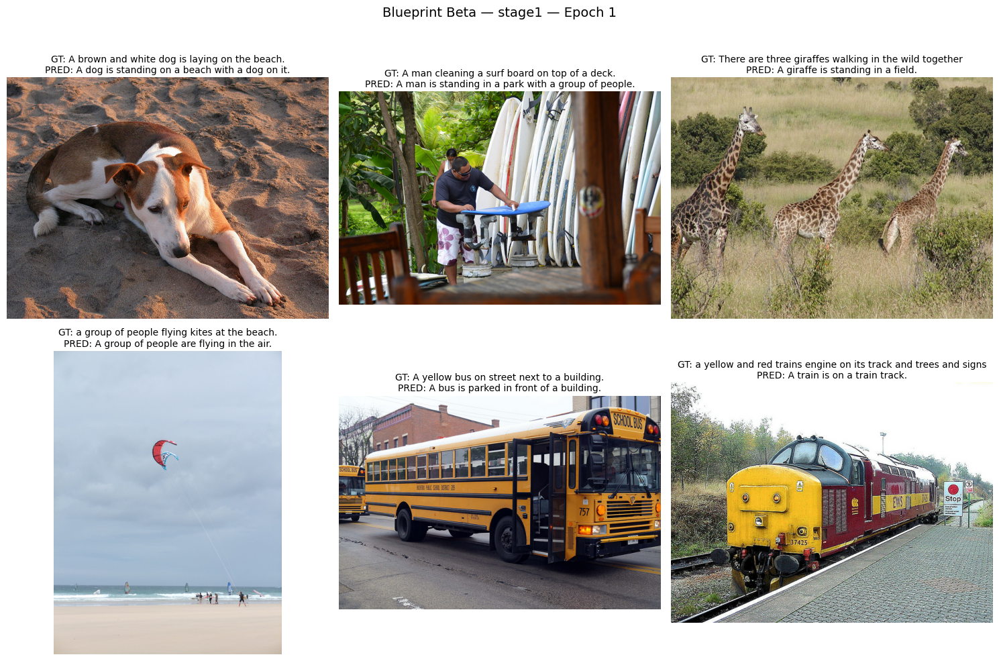

[resume checkpoint] /kaggle/working/alpha_captioner/blueprint_beta_checkpoints/last.pt


stage1 epoch 2/3:   0%|          | 0/1479 [00:00<?, ?batch/s]

Epoch 02 | stage1 2/3 | train=2.7268 | val=2.6601 | epoch_time=01:10:54 | stage_ETA=01:11:03 | GPU_alloc=0.64GB | GPU_reserved=10.99GB | GPU_peak=8.92GB | RAM_used=7.17GB | RAM_free=21.97GB | LRs=['3.03e-04']
[best checkpoint] /kaggle/working/alpha_captioner/blueprint_beta_checkpoints/stage1_best.pt | val_loss=2.6601

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000466217.jpg
GT   : A brown and white dog is laying on the beach.
Pred : A dog is standing on a beach.

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000491879.jpg
GT   : A man cleaning a surf board on top of a deck.
Pred : A man is sitting on a chair with a chair in front of him.

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000120060.jpg
GT   : There are three giraffes walking in the wild together
Pred : A giraffe is standing in a field with a bunch of giraffes.

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/t

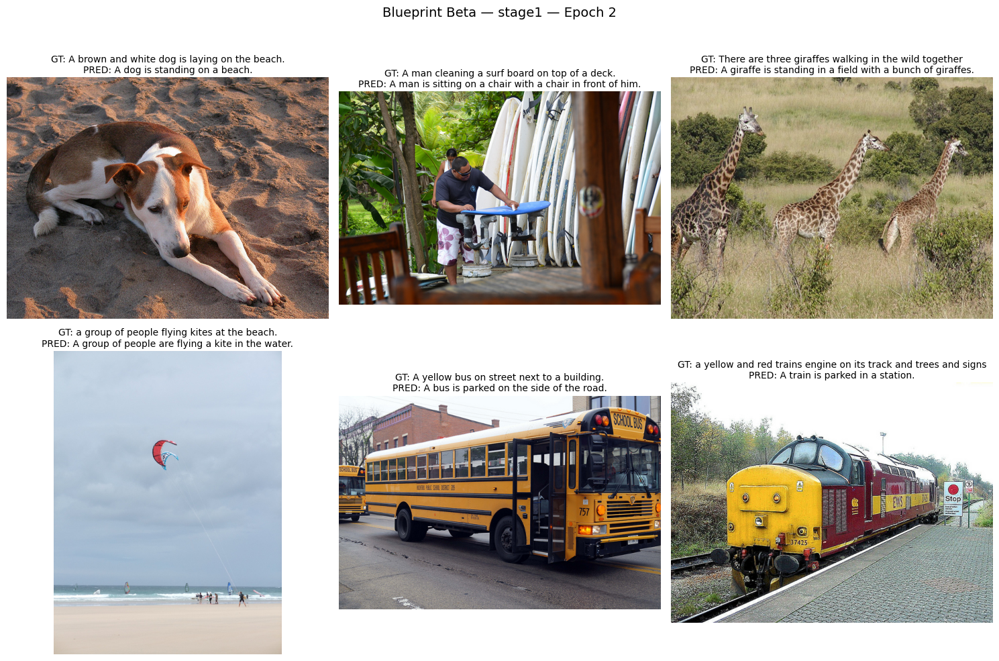

[resume checkpoint] /kaggle/working/alpha_captioner/blueprint_beta_checkpoints/last.pt


stage1 epoch 3/3:   0%|          | 0/1479 [00:00<?, ?batch/s]

Epoch 03 | stage1 3/3 | train=2.6853 | val=2.6419 | epoch_time=01:11:02 | stage_ETA=00:00:00 | GPU_alloc=0.66GB | GPU_reserved=11.03GB | GPU_peak=8.92GB | RAM_used=7.22GB | RAM_free=21.92GB | LRs=['6.67e-05']
[best checkpoint] /kaggle/working/alpha_captioner/blueprint_beta_checkpoints/stage1_best.pt | val_loss=2.6419

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000466217.jpg
GT   : A brown and white dog is laying on the beach.
Pred : A dog is sitting on a rock.

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000491879.jpg
GT   : A man cleaning a surf board on top of a deck.
Pred : A man is sitting on a chair with a chair in front of him.

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000120060.jpg
GT   : There are three giraffes walking in the wild together
Pred : A giraffe is standing in a field.

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000307940.jpg
G

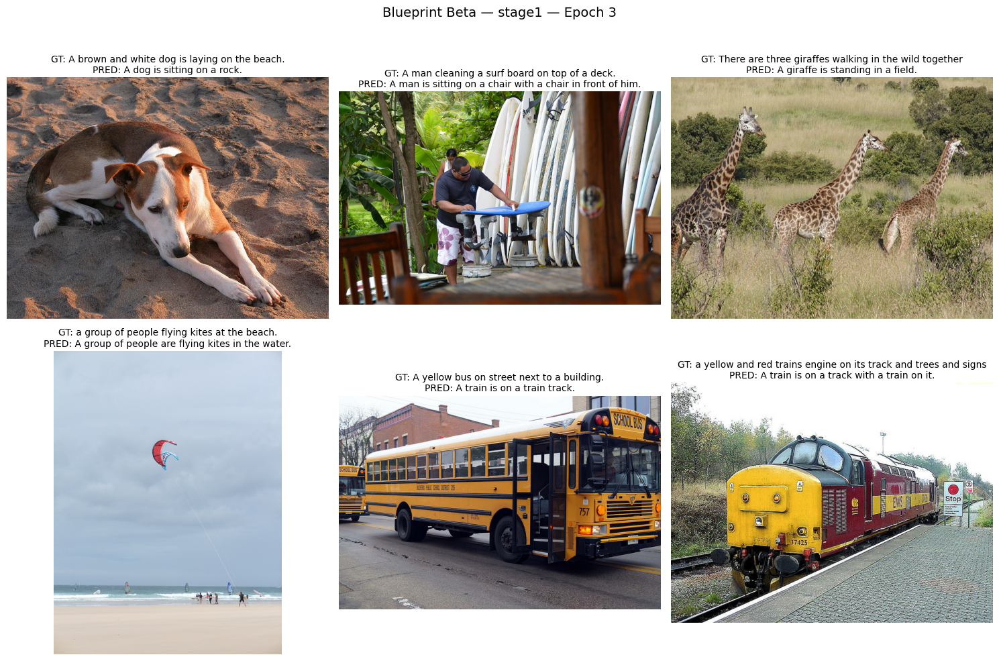

[resume checkpoint] /kaggle/working/alpha_captioner/blueprint_beta_checkpoints/last.pt
Total multimodal params: 148.28M
Currently trainable params: 3.03M

===== START STAGE2 | epochs=2 | batch=64 | steps/epoch=1479 =====


stage2 epoch 1/2:   0%|          | 0/1479 [00:00<?, ?batch/s]

Epoch 04 | stage2 1/2 | train=2.5219 | val=2.3054 | epoch_time=01:21:40 | stage_ETA=01:21:41 | GPU_alloc=0.70GB | GPU_reserved=14.41GB | GPU_peak=12.14GB | RAM_used=8.76GB | RAM_free=20.20GB | LRs=['1.14e-04', '4.56e-05']
[best checkpoint] /kaggle/working/alpha_captioner/blueprint_beta_checkpoints/stage2_best.pt | val_loss=2.3054

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000466217.jpg
GT   : A brown and white dog is laying on the beach.
Pred : A dog is standing on a beach with a white dog.

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000491879.jpg
GT   : A man cleaning a surf board on top of a deck.
Pred : A man in a suit and tie is sitting on a bench.

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000120060.jpg
GT   : There are three giraffes walking in the wild together
Pred : A giraffe standing in a field with other giraffes.

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset

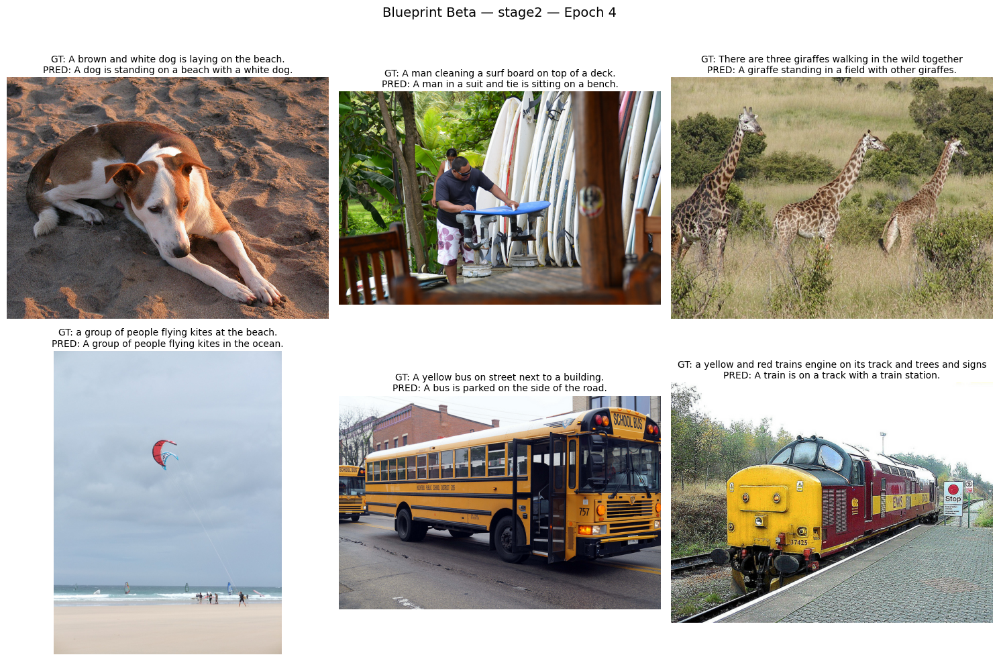

[resume checkpoint] /kaggle/working/alpha_captioner/blueprint_beta_checkpoints/last.pt


stage2 epoch 2/2:   0%|          | 0/1479 [00:00<?, ?batch/s]

Epoch 05 | stage2 2/2 | train=2.3736 | val=2.2846 | epoch_time=01:21:39 | stage_ETA=00:00:00 | GPU_alloc=0.67GB | GPU_reserved=14.29GB | GPU_peak=12.14GB | RAM_used=6.82GB | RAM_free=22.31GB | LRs=['6.67e-05', '2.67e-05']
[best checkpoint] /kaggle/working/alpha_captioner/blueprint_beta_checkpoints/stage2_best.pt | val_loss=2.2846

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000466217.jpg
GT   : A brown and white dog is laying on the beach.
Pred : A brown and white dog laying on the ground.

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000491879.jpg
GT   : A man cleaning a surf board on top of a deck.
Pred : A man in a suit and tie is sitting on a bench.

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000120060.jpg
GT   : There are three giraffes walking in the wild together
Pred : A group of giraffes standing in a field.

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/tra

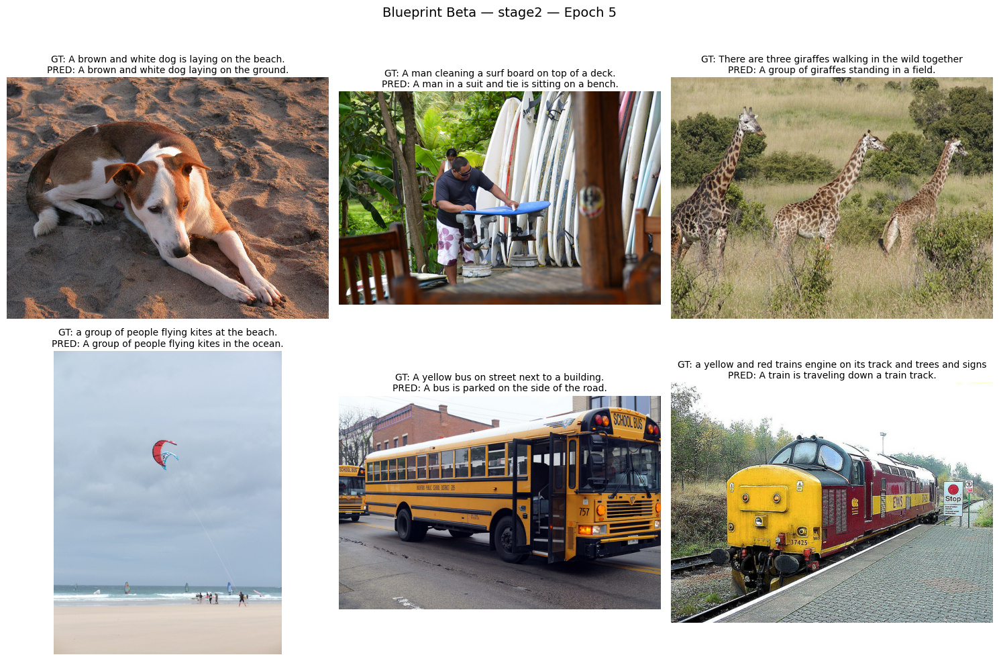

[resume checkpoint] /kaggle/working/alpha_captioner/blueprint_beta_checkpoints/last.pt
===== TRAINING COMPLETE =====


In [17]:
# Save a human-readable run configuration before training starts.
run_config = {
    "vision_model": VISION_MODEL_NAME,
    "text_model": TEXT_MODEL_NAME,
    "image_size": IMAGE_SIZE,
    "target_visual_grid": TARGET_VISUAL_GRID,
    "pixel_unshuffle_factor": PIXEL_UNSHUFFLE_FACTOR,
    "visual_tokens": NUM_VISUAL_TOKENS,
    "vision_channels": VISION_CHANNELS,
    "text_hidden": TEXT_HIDDEN,
    "stage1_epochs": STAGE1_EPOCHS,
    "stage2_epochs": STAGE2_EPOCHS,
    "stage2_patience": STAGE2_PATIENCE,
    "stage2_min_delta": STAGE2_MIN_DELTA,
    "batch_candidates": BATCH_CANDIDATES,
    "lr_reference_batch_size": LR_REFERENCE_BATCH_SIZE,
    "lr_scale": LR_SCALE,
    "stage1_weight_decay": STAGE1_WEIGHT_DECAY,
    "stage2_weight_decay": STAGE2_WEIGHT_DECAY,
    "connector_stage1_dropout": CONNECTOR_STAGE1_DROPOUT,
    "connector_stage2_dropout": CONNECTOR_STAGE2_DROPOUT,
    "selected_batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "amp_dtype": str(AMP_DTYPE),
    "lora_r": LORA_R,
    "lora_alpha": LORA_ALPHA,
    "lora_dropout": LORA_DROPOUT,
    "adapt_lm_head": ADAPT_LM_HEAD,
    "lora_targets": LORA_TARGET_MODULES,
    "explicit_bos_token": True,
    "vision_augmentation": {
        "stage1": "hflip=0.5, color_jitter=0.10, re_prob=0.05",
        "stage2": "hflip=0.5, color_jitter=0.20, re_prob=0.15, re_mode=pixel",
    },
    "seed": SEED,
}
CONFIG_PATH.write_text(json.dumps(run_config, indent=2), encoding="utf-8")

# Create the validation loader now that the batch size is known.
valid_dataset.set_stage("eval")
valid_loader = make_loader(valid_dataset, BATCH_SIZE, shuffle=False, drop_last=False)

# Determine resume point.
resume_ckpt = None
if RESUME_PATH.exists():
    try:
        candidate_ckpt = torch.load(RESUME_PATH, map_location="cpu", weights_only=False)
        candidate_schedule = candidate_ckpt.get("schedule", {})
        candidate_model_cfg = candidate_ckpt.get("model", {})
        candidate_lora_targets = candidate_ckpt.get(
            "lora_targets",
            candidate_model_cfg.get("lora_targets", []),
        )

        compatible = (
            int(candidate_schedule.get("stage1_epochs", -1)) == STAGE1_EPOCHS
            and int(candidate_schedule.get("stage2_epochs", -1)) == STAGE2_EPOCHS
            and abs(float(candidate_schedule.get("stage2_weight_decay", -1)) - STAGE2_WEIGHT_DECAY) < 1e-12
            and list(candidate_lora_targets) == list(LORA_TARGET_MODULES)
            and bool(candidate_model_cfg.get("explicit_bos_token", True)) is True
        )
        if compatible:
            # Only load model-side state after schedule compatibility is confirmed.
            model.connector.load_state_dict(candidate_ckpt["connector_state"])
            if candidate_ckpt.get("lora_state"):
                set_peft_model_state_dict(model.text_decoder, candidate_ckpt["lora_state"])
            resume_ckpt = candidate_ckpt
            print(f"Found compatible resume checkpoint: {RESUME_PATH}")
            print(f"Checkpoint stage={resume_ckpt['stage']} epoch={resume_ckpt['epoch']} global_step={resume_ckpt['global_step']}")
        else:
            print("Existing checkpoint uses an older schedule; starting a fresh run.")
            resume_ckpt = None
    except Exception as e:
        print(f"Resume checkpoint could not be loaded; starting fresh. Reason: {e}")
        resume_ckpt = None


def set_lora_dropout(text_decoder, probability):
    for module in text_decoder.modules():
        if hasattr(module, "lora_dropout"):
            container = module.lora_dropout
            if hasattr(container, "values"):
                for dropout in container.values():
                    if isinstance(dropout, nn.Dropout):
                        dropout.p = float(probability)


def set_stage_mode(stage):
    model.vision_encoder.eval()
    model.vision_encoder.requires_grad_(False)
    model.connector.train()
    if stage == "stage1":
        model.connector.set_dropout(CONNECTOR_STAGE1_DROPOUT)
        set_lora_dropout(model.text_decoder, 0.0)
        model.text_decoder.eval()
        for p in model.text_decoder.parameters():
            p.requires_grad_(False)
    else:
        model.connector.set_dropout(CONNECTOR_STAGE2_DROPOUT)
        set_lora_dropout(model.text_decoder, LORA_DROPOUT)
        model.text_decoder.train()
        for name, p in model.text_decoder.named_parameters():
            p.requires_grad_("lora_" in name)


def train_stage(stage, start_epoch, num_epochs, global_step, best_val_loss):
    stage_dataset = train_dataset
    stage_dataset.stage = stage
    train_loader = make_loader(stage_dataset, BATCH_SIZE, shuffle=True, drop_last=False)
    valid_dataset.set_stage("eval")  # stable validation prompt/caption selection
    valid_loader = make_loader(valid_dataset, BATCH_SIZE, shuffle=False, drop_last=False)

    steps_per_epoch = len(train_loader)
    total_steps = num_epochs * steps_per_epoch
    optimizer, scheduler, scaler, trainable_params = build_stage_optimizer(stage, total_steps)

    # Restore optimizer state only when resuming the same stage.
    if resume_ckpt is not None and resume_ckpt.get("stage") == stage:
        optimizer.load_state_dict(resume_ckpt["optimizer_state"])
        scheduler.load_state_dict(resume_ckpt["scheduler_state"])
        scaler.load_state_dict(resume_ckpt["scaler_state"])
        best_val_loss = float(resume_ckpt.get("best_val_loss", best_val_loss))

    print_parameter_summary()
    log_line(f"\n===== START {stage.upper()} | epochs={num_epochs} | batch={BATCH_SIZE} | steps/epoch={steps_per_epoch} =====")

    stage_start_time = time.perf_counter()
    completed_epochs = 0
    epochs_without_improvement = 0

    for local_epoch in range(start_epoch + 1, num_epochs + 1):
        global_epoch_number = (0 if stage == "stage1" else STAGE1_EPOCHS) + local_epoch
        stage_dataset.set_epoch(global_epoch_number - 1)
        valid_dataset.set_epoch(0)
        set_stage_mode(stage)
        torch.cuda.reset_peak_memory_stats()

        epoch_start = time.perf_counter()
        running_loss = 0.0
        seen_examples = 0

        pbar = tqdm(
            train_loader,
            desc=f"{stage} epoch {local_epoch}/{num_epochs}",
            unit="batch",
            dynamic_ncols=True,
        )

        optimizer.zero_grad(set_to_none=True)
        for batch_idx, batch in enumerate(pbar, start=1):
            batch_gpu = move_batch(batch)
            with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
                loss, _ = model(
                    batch_gpu["pixel_values"],
                    batch_gpu["input_ids"],
                    batch_gpu["attention_mask"],
                    batch_gpu["labels"],
                )

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(trainable_params, MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()

            bs = batch_gpu["pixel_values"].size(0)
            running_loss += loss.item() * bs
            seen_examples += bs
            global_step += 1

            elapsed = time.perf_counter() - epoch_start
            rate = seen_examples / max(elapsed, 1e-6)
            avg_loss = running_loss / max(seen_examples, 1)
            remaining_batches = len(train_loader) - batch_idx
            eta_epoch = (elapsed / batch_idx) * remaining_batches if batch_idx else float("nan")

            pbar.set_postfix(
                loss=f"{avg_loss:.4f}",
                img_s=f"{rate:.1f}",
                ETA=fmt_seconds(eta_epoch),
            )

        train_loss = running_loss / max(seen_examples, 1)
        val_loss = evaluate_loss(valid_loader)
        completed_epochs += 1

        epoch_time = time.perf_counter() - epoch_start
        total_elapsed = time.perf_counter() - stage_start_time
        completed_stage_epochs = completed_epochs
        remaining_stage_epochs = num_epochs - local_epoch
        eta_seconds = (total_elapsed / max(completed_stage_epochs, 1)) * remaining_stage_epochs

        mem = memory_report()
        lrs = [pg["lr"] for pg in optimizer.param_groups]

        log_line(
            f"Epoch {global_epoch_number:02d} | {stage} {local_epoch}/{num_epochs} | "
            f"train={train_loss:.4f} | val={val_loss:.4f} | "
            f"epoch_time={fmt_seconds(epoch_time)} | stage_ETA={fmt_seconds(eta_seconds)} | "
            f"GPU_alloc={mem['gpu_alloc_gb']:.2f}GB | GPU_reserved={mem['gpu_reserved_gb']:.2f}GB | "
            f"GPU_peak={mem['gpu_peak_gb']:.2f}GB | RAM_used={mem['ram_used_gb']:.2f}GB | "
            f"RAM_free={mem['ram_available_gb']:.2f}GB | "
            f"LRs={[f'{x:.2e}' for x in lrs]}"
        )

        metric_row = {
            "global_epoch": global_epoch_number,
            "stage": stage,
            "stage_epoch": local_epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "epoch_seconds": epoch_time,
            "eta_stage_seconds": eta_seconds,
            "batch_size": BATCH_SIZE,
            "lr_scale": LR_SCALE,
            "stage_weight_decay": STAGE1_WEIGHT_DECAY if stage == "stage1" else STAGE2_WEIGHT_DECAY,
            "train_images": seen_examples,
            **mem,
            "global_step": global_step,
        }
        append_metric(metric_row)

        # Best checkpoint + Stage-2 early stopping.
        improved = val_loss < best_val_loss - (STAGE2_MIN_DELTA if stage == "stage2" else 0.0)
        if improved:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            best_path = save_best(stage, local_epoch, global_step, optimizer, scheduler, scaler, best_val_loss)
            log_line(f"[best checkpoint] {best_path} | val_loss={best_val_loss:.4f}")
        elif stage == "stage2":
            epochs_without_improvement += 1

        # Visual audit every epoch.
        save_epoch_predictions(global_epoch_number, stage)

        # Always overwrite the main resume point at the epoch boundary.
        save_resume(stage, local_epoch, global_step, optimizer, scheduler, scaler, best_val_loss)
        log_line(f"[resume checkpoint] {RESUME_PATH}")

        gc.collect()
        torch.cuda.empty_cache()

        if stage == "stage2" and epochs_without_improvement >= STAGE2_PATIENCE:
            log_line(
                f"[early stopping] Stage 2 stopped after {local_epoch} epochs "
                f"without validation improvement beyond delta={STAGE2_MIN_DELTA}."
            )
            break

    return global_step, best_val_loss

# Initialize counters based on an existing checkpoint, if present.
global_step = 0
best_val_loss = float("inf")

if resume_ckpt is None:
    start_stage = "stage1"
    start_stage_epoch = 0
elif resume_ckpt["stage"] == "stage1":
    global_step = int(resume_ckpt["global_step"])
    if int(resume_ckpt["epoch"]) < STAGE1_EPOCHS:
        start_stage = "stage1"
        start_stage_epoch = int(resume_ckpt["epoch"])
        best_val_loss = float(resume_ckpt.get("best_val_loss", float("inf")))
    else:
        # Stage 1 is complete: resume at the beginning of Stage 2.
        start_stage = "stage2"
        start_stage_epoch = 0
        best_val_loss = float("inf")
elif resume_ckpt["stage"] == "stage2" and int(resume_ckpt["epoch"]) < STAGE2_EPOCHS:
    start_stage = "stage2"
    start_stage_epoch = int(resume_ckpt["epoch"])
    global_step = int(resume_ckpt["global_step"])
    best_val_loss = float(resume_ckpt.get("best_val_loss", float("inf")))
else:
    # Stage 2 is already complete; do not train again.
    start_stage = "stage2"
    start_stage_epoch = STAGE2_EPOCHS
    global_step = int(resume_ckpt.get("global_step", 0)) if resume_ckpt else 0
    best_val_loss = float(resume_ckpt.get("best_val_loss", float("inf"))) if resume_ckpt else float("inf")

# Train Stage 1 if needed.
if start_stage == "stage1" and start_stage_epoch < STAGE1_EPOCHS:
    global_step, best_val_loss = train_stage("stage1", start_stage_epoch, STAGE1_EPOCHS, global_step, best_val_loss)
    start_stage = "stage2"
    start_stage_epoch = 0
    best_val_loss = float("inf")

# Train Stage 2 if needed.
if start_stage == "stage2" and start_stage_epoch < STAGE2_EPOCHS:
    global_step, best_val_loss = train_stage("stage2", start_stage_epoch, STAGE2_EPOCHS, global_step, best_val_loss)

log_line("===== TRAINING COMPLETE =====")

# 15. Final model checkpoint

The final checkpoint is a compact multimodal state package: connector weights + LoRA adapters + metadata. It does not duplicate the pretrained MobileCLIP or SmolLM2 base weights.

For inference or later training, the notebook reconstructs the base model from the same Hugging Face identifiers and then applies this checkpoint.

In [18]:
# Rebuild a lightweight final checkpoint from the final trained weights.
final_adapter = get_peft_model_state_dict(model.text_decoder)
final_payload = {
    "format_version": 2,
    "saved_at": datetime.now().isoformat(),
    "model": run_config,
    "connector_state": {k: v.detach().cpu() for k, v in model.connector.state_dict().items()},
    "lora_state": {k: v.detach().cpu() for k, v in final_adapter.items()},
    "selected_batch_size": BATCH_SIZE,
}
atomic_torch_save(final_payload, FINAL_PATH)
print(f"Saved final compact checkpoint: {FINAL_PATH}")
print(f"Checkpoint size: {FINAL_PATH.stat().st_size / (1024**2):.2f} MB")

Saved final compact checkpoint: /kaggle/working/alpha_captioner/blueprint_beta_checkpoints/beta_final.pt
Checkpoint size: 11.71 MB


# 16. Training curves and batch benchmark

The batch benchmark and epoch metrics are saved in `/kaggle/working/blueprint_beta_artifacts/`.

,batch_size,fits,peak_vram_gb,images_per_sec
0,48,True,8.279639,19.376278
1,64,True,10.931592,24.300716
2,80,False,13.583647,23.826537


,global_epoch,stage,stage_epoch,train_loss,val_loss,epoch_seconds,eta_stage_seconds,batch_size,lr_scale,stage_weight_decay,train_images,gpu_alloc_gb,gpu_reserved_gb,gpu_peak_gb,ram_used_gb,ram_available_gb,global_step
0,1,stage1,1,2.955375,2.737085,4260.631779,8521.306080,64,1.333333,0.01,94629,0.641814,10.968750,8.915950,6.546551,22.591553,1479
1,2,stage1,2,2.726753,2.660079,4254.389747,4263.866634,64,1.333333,0.01,94629,0.638427,10.988281,8.915950,7.170261,21.967842,2958
2,3,stage1,3,2.685323,2.641922,4262.257227,0.000000,64,1.333333,0.01,94629,0.655368,11.027344,8.915950,7.217953,21.920151,4437
3,4,stage2,1,2.521868,2.305430,4900.990292,4901.013655,64,1.333333,0.05,94629,0.697282,14.406250,12.135222,8.756618,20.203674,5916
4,5,stage2,2,2.373576,2.284633,4899.208589,0.000000,64,1.333333,0.05,94629,0.673564,14.289062,12.135222,6.821102,22.314972,7395


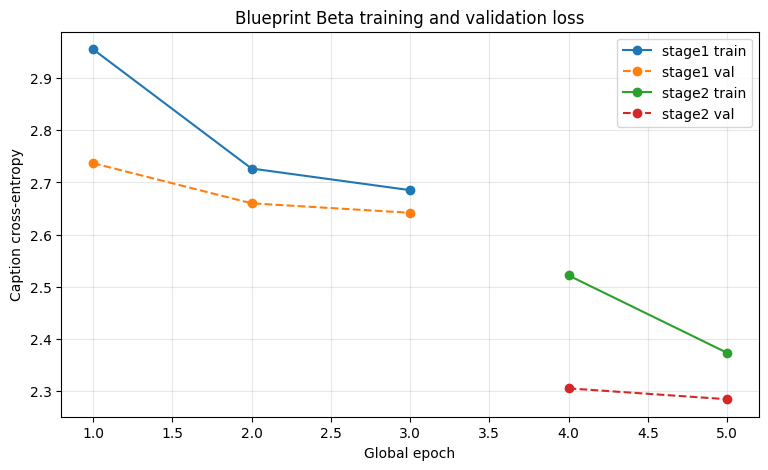

In [19]:
if batch_benchmark_rows:
    display(pd.DataFrame(batch_benchmark_rows))

if METRICS_PATH.exists():
    metrics_df = pd.read_csv(METRICS_PATH)
    display(metrics_df)
    plt.figure(figsize=(9, 5))
    for stage_name, g in metrics_df.groupby("stage"):
        plt.plot(g["global_epoch"], g["train_loss"], marker="o", label=f"{stage_name} train")
        plt.plot(g["global_epoch"], g["val_loss"], marker="o", linestyle="--", label=f"{stage_name} val")
    plt.xlabel("Global epoch")
    plt.ylabel("Caption cross-entropy")
    plt.title("Blueprint Beta training and validation loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

# 17. Final qualitative test on COCO val2017

This uses the same trained model and displays unseen `val2017` images with one reference caption and the generated caption.


Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017/000000575243.jpg
GT   : A person walking down a street while holding an umbrella.
Pred : A man walking down a street with a umbrella.

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017/000000292024.jpg
GT   : A woman wearing glasses looking at slices of pizza
Pred : A woman is sitting at a table with a pizza.

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017/000000553669.jpg
GT   : People sitting on benches in the park, and traffic in the street
Pred : A man and woman sitting on a bench in a park.

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017/000000113235.jpg
GT   : A hand is holding a carrot for a llama to chew.
Pred : A dog is holding a red frisbee in its mouth.

Image: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017/000000424521.jpg
GT   : A shirtless man doing skateboarding tricks near a stream
Pred : A man riding a s

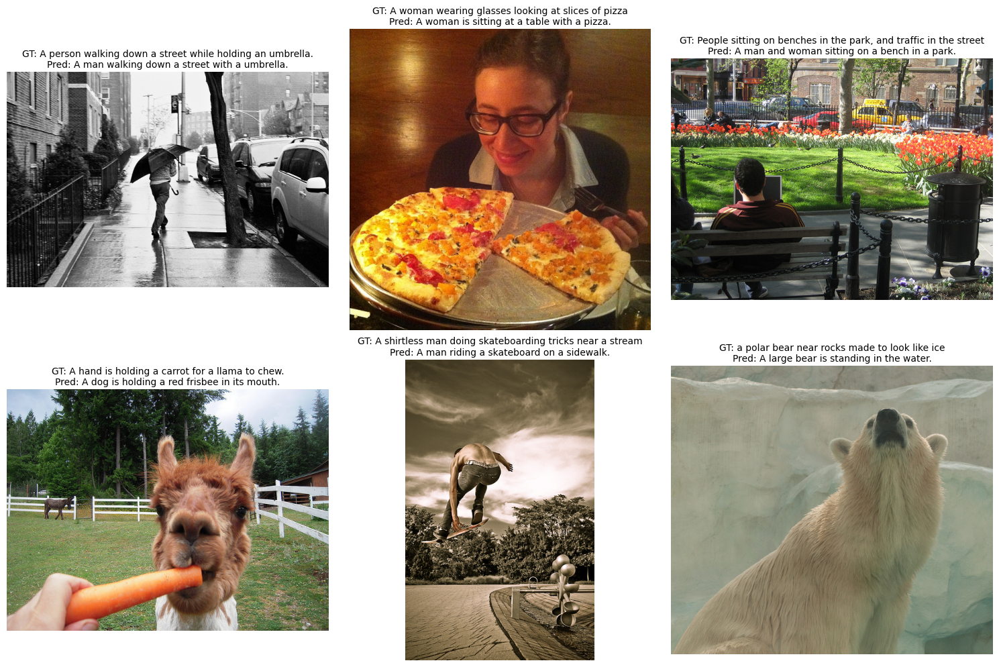

In [20]:
@torch.no_grad()
def show_test_predictions(n_samples=6):
    model.eval()
    model.vision_encoder.eval()
    model.text_decoder.eval()

    rng = np.random.default_rng(SEED + 123)
    picks = rng.choice(len(test_groups), size=min(n_samples, len(test_groups)), replace=False)
    selected = [test_groups[int(i)] for i in picks]

    rows = []
    fig, axes = plt.subplots(math.ceil(len(selected) / 3), 3, figsize=(15, 5 * math.ceil(len(selected) / 3)))
    axes = np.array(axes).reshape(-1)

    for ax, (image_path, captions) in zip(axes, selected):
        image = Image.open(image_path).convert("RGB")
        #x = vision_transform(image).unsqueeze(0).to(device)
        x = vision_transform_eval(image).unsqueeze(0).to(device)
        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            pred = model.generate_caption(x, prompt="Write a concise caption for this image:", max_new_tokens=30)[0]
        gt = captions[0]
        ax.imshow(image)
        ax.axis("off")
        ax.set_title(f"GT: {gt}\nPred: {pred}", fontsize=10, wrap=True)
        rows.append({"image_filepath": image_path, "ground_truth": gt, "prediction": pred})
        print(f"\nImage: {image_path}\nGT   : {gt}\nPred : {pred}")

    for ax in axes[len(selected):]:
        ax.axis("off")
    fig.tight_layout()
    final_png = ARTIFACT_DIR / "final_val2017_predictions.png"
    fig.savefig(final_png, dpi=140, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    pd.DataFrame(rows).to_csv(ARTIFACT_DIR / "final_val2017_predictions.csv", index=False)
    with open(ARTIFACT_DIR / "final_val2017_predictions.json", "w", encoding="utf-8") as f:
        json.dump(rows, f, indent=2, ensure_ascii=False)

show_test_predictions(n_samples=6)

# 18. Resume / reload reference

The compact checkpoint can be restored after a Kaggle session restart by loading the same base model IDs and applying `last.pt` or `beta_final.pt`.

The main training loop is already resume-aware: rerunning the notebook detects `/kaggle/working/blueprint_beta_checkpoints/last.pt`, restores the multimodal weights and optimizer state, and continues from the recorded epoch/stage.

In [21]:
# Manual inspection helpers
print("Checkpoint directory:")
for p in sorted(CHECKPOINT_DIR.glob("*.pt")):
    print(f" - {p.name:24s} {p.stat().st_size / (1024**2):8.2f} MB")

print("\nArtifact directory:")
for p in sorted(ARTIFACT_DIR.iterdir()):
    print(f" - {p.name}")

Checkpoint directory:
 - beta_final.pt               11.71 MB
 - last.pt                     35.20 MB
 - stage1_best.pt              16.23 MB
 - stage2_best.pt              35.21 MB

Artifact directory:
 - epoch_01_stage1_predictions.csv
 - epoch_01_stage1_predictions.json
 - epoch_01_stage1_predictions.png
 - epoch_02_stage1_predictions.csv
 - epoch_02_stage1_predictions.json
 - epoch_02_stage1_predictions.png
 - epoch_03_stage1_predictions.csv
 - epoch_03_stage1_predictions.json
 - epoch_03_stage1_predictions.png
 - epoch_04_stage2_predictions.csv
 - epoch_04_stage2_predictions.json
 - epoch_04_stage2_predictions.png
 - epoch_05_stage2_predictions.csv
 - epoch_05_stage2_predictions.json
 - epoch_05_stage2_predictions.png
 - final_val2017_predictions.csv
 - final_val2017_predictions.json
 - final_val2017_predictions.png
 - metrics.csv
 - run_config.json
 - training.log


## Source alignment summary

The implementation follows the supplied PDF at the level that is directly actionable in the notebook:

- **Blueprint Beta:** MobileCLIP-family vision encoder + PixelShuffle/space-to-depth token reduction + SmolLM2-135M causal decoder.
- **64-token visual prefix:** 16×16 spatial feature map reduced by factor 2 per spatial dimension.
- **Two-stage optimization:** connector-only alignment, then connector + language adaptation with the vision encoder frozen.
- **Context control:** visual prefix is fixed at 64 tokens and text is capped so the training context remains well below the document’s 128-token target.
- **Hallucination monitoring:** qualitative per-epoch image/GT/prediction records are preserved, which is useful for catching language-prior failures that scalar loss can hide.

- **Explicit BOS handling:** training and generation use `[visual prefix] + [BOS] + [prompt] + [caption] + [EOS]`.
- **Cached generation attention mask:** the attention mask is extended at every generated token to suppress repeated transformers warnings without changing the causal context.
- **Stage-2 output adaptation:** the base language-model head stays frozen while a low-rank adapter can specialize `lm_head` for caption generation.

Where the source document leaves implementation-level details unspecified (for example, exact LoRA rank or exact T4 batch size), this notebook treats those as engineering parameters and measures the hardware-sensitive ones at runtime rather than presenting them as source-derived facts.